# Merchant Fraud-Risk Modelling

This notebook builds one retrospective risk-estimation row per merchant, uses the 61 directly labelled merchants as training targets, compares five models, and scores all 4,422 merchants. The output supports merchant-ranking review; it is not proof of fraud.

In [1]:
import os
import sys
import tempfile
from pathlib import Path

import duckdb
import pandas as pd
from IPython.display import Image, display

def find_member4_dir(start=Path.cwd().resolve()):
    for candidate in (start, *start.parents):
        direct = candidate if candidate.name == 'member4_fraud' else candidate / 'member4_fraud'
        if (direct / 'code').is_dir():
            return direct
    raise FileNotFoundError('Run this notebook from the repository or member4_fraud/code.')

MODULE_DIR = find_member4_dir()
CODE_DIR = MODULE_DIR / 'code'
REPO_ROOT = MODULE_DIR.parent
OUTPUT_DIR = Path(tempfile.gettempdir()) / 'member4_fraud_work' / 'merchant_model'
DELIVERY_DIR = MODULE_DIR / 'result'
RAW_TABLES = Path(os.environ.get('MEMBER4_RAW_TABLES', REPO_ROOT.parent / 'data' / 'part1' / 'tables'))
CURATED_TRANSACTIONS = Path(os.environ.get('MEMBER4_CURATED_TRANSACTIONS', REPO_ROOT / 'member2_curation' / 'data' / 'curated' / 'curated_transactions'))
if str(CODE_DIR) not in sys.path:
    sys.path.insert(0, str(CODE_DIR))
print(sys.executable)

C:\Users\十五\OneDrive\Desktop\ads project 2\.venv\Scripts\python.exe


## 1. Modelling definition

The supplied merchant table has 114 dated scores for only 61 merchants. To match the final ranking grain and prevent the same merchant appearing in multiple splits, the dated scores are averaged to one target per merchant. `merchant_abn` and the direct fraud score are never input features.

Transaction features are calculated up to 28 February 2022. Consumer-day predictions are merged through `user_id` and aggregated into merchant exposure measures. Static merchant metadata is joined through `merchant_abn`.

## 2. Build the merchant feature tables

The scoring table contains every merchant. The training table is the 61-row labelled subset. Direct merchant fraud probability remains the target and is not used to create predictors.

In [2]:
from build_merchant_model_table import build_merchant_model_table

merchant_table_summary = build_merchant_model_table(
    repo_root=REPO_ROOT, raw_tables_root=RAW_TABLES, output_dir=OUTPUT_DIR,
    curated_transactions_root=CURATED_TRANSACTIONS
)
display(merchant_table_summary)

,table_name,rows,merchants,mean_target,mean_consumer_risk_coverage
0,scoring,4422,4422,NaN,1.0
1,training,61,61,0.458362,1.0


In [3]:
TRAINING_PATH = OUTPUT_DIR / 'merchant_fraud_training_table.parquet'
SCORING_PATH = OUTPUT_DIR / 'merchant_scoring_features_2022-02-28.parquet'
training_preview = duckdb.sql(f"""
    SELECT merchant_abn, fraud_probability, target_observations,
           log_total_revenue, repeat_consumer_share, sales_growth_log,
           amount_weighted_consumer_risk, high_risk_revenue_share
    FROM read_parquet('{TRAINING_PATH.as_posix()}') LIMIT 8
""").df()
display(training_preview)

,merchant_abn,fraud_probability,target_observations,log_total_revenue,repeat_consumer_share,sales_growth_log,amount_weighted_consumer_risk,high_risk_revenue_share
0,11149063370,0.532869,3,13.640280,0.000000,0.028983,0.119650,NaN
1,11470993597,0.633773,1,9.709363,0.003817,-0.456064,0.141698,0.115412
2,11590404675,0.296078,1,13.195827,0.000000,-0.918001,0.125836,NaN
3,14530561097,0.808005,1,14.102164,0.000000,-0.060632,0.147236,0.025722
4,14827550074,0.420006,4,15.173349,0.012195,-0.225597,0.131151,0.022982
5,15043504837,0.369854,3,14.473169,0.000000,0.625099,0.131885,NaN
6,15157368385,0.642774,1,9.860422,0.000000,-0.828680,0.156262,0.075700
7,18158387243,0.290297,2,15.496777,0.180361,0.055577,0.143478,0.088491


## 3. New merged feature groups

**Merchant activity:** revenue, order value, consumer count, repeat share, recency, 30/90-day activity, growth, stability and high-value share.

**Consumer-risk exposure:** calculated for the later risk-combination stage, but excluded from KNN predictors to avoid counting the same consumer signal twice.

**Static merchant metadata:** take rate is retained. High-cardinality names, ABNs, categories and external demographics are excluded from this first model because 61 labels cannot support many additional parameters.

## 4. Validation and overfitting controls

- One row per merchant prevents repeated dates for the same merchant leaking across splits.
- 48 merchants form the model-selection pool; 13 stratified merchants are held out until the end.
- Hyperparameters are compared with repeated five-fold CV (5 folds × 10 repeats) on the 48 training merchants.
- Imputation and scaling are fitted inside each fold.
- Selection uses mean CV MAE, with CV RMSE as tie-breaker.
- Trees are shallow/regularized and KNN uses limited neighbour choices.
- The independent test set is evaluated only after every model form is fixed.

In [4]:
from train_merchant_models import MODEL_FEATURES, run_merchant_model_experiment

merchant_model_comparison = run_merchant_model_experiment(
    repo_root=REPO_ROOT, output_dir=OUTPUT_DIR
)
display(merchant_model_comparison)

,model,selected_by_cv,best_parameters,cv_mae_mean,cv_mae_std,cv_rmse_mean,cv_r2_mean,cv_spearman_mean,cv_spearman_std,train_mae,test_mae,test_rmse,test_r2,test_spearman,test_minus_train_mae
0,KNN,True,"{""n_features"": 8, ""n_neighbors"": 8, ""p"": 1, ""t...",0.092457,0.033600,0.137639,0.275539,0.676652,0.206722,0.000000,0.114028,0.186480,0.299711,0.423077,0.114028
1,XGBoost,False,"{""colsample_bytree"": 0.8, ""learning_rate"": 0.0...",0.106565,0.034416,0.149353,0.181923,0.538200,0.216434,0.047478,0.117367,0.214090,0.076991,0.406593,0.069889
2,Random Forest,False,"{""max_depth"": 4, ""max_features"": 0.7, ""min_sam...",0.115981,0.033308,0.153586,0.163616,0.483023,0.220359,0.066186,0.118931,0.201368,0.183424,0.362637,0.052744
3,Linear Regression,False,"{""fit_intercept"": true}",0.132505,0.043620,0.180593,-0.211845,0.564831,0.231414,0.076596,0.172506,0.217582,0.046630,0.428571,0.095910
4,Mean Baseline,False,{},0.177915,0.024313,0.196363,-0.306449,0.000000,0.000000,0.173224,0.191785,0.222902,-0.000559,0.000000,0.018562


In [5]:
split_summary = pd.read_csv(OUTPUT_DIR / 'merchant_data_split_summary.csv')
diagnostics = pd.read_csv(OUTPUT_DIR / 'merchant_feature_diagnostics.csv')
high_correlations = pd.read_csv(OUTPUT_DIR / 'merchant_high_correlation_pairs.csv')
vif = pd.read_csv(OUTPUT_DIR / 'merchant_vif.csv')
display(split_summary, diagnostics.sort_values('target_spearman', key=abs, ascending=False),
        high_correlations.head(20), vif.head(20))

,split,merchants,mean_target,min_target,max_target
0,train_for_cv,48,0.457239,0.182109,0.910961
1,held_out_test,13,0.462507,0.277933,0.941347


,feature,missing_rate,unique_values,standard_deviation,target_pearson,target_spearman
0,log_total_revenue,0.000000,61,1.978067,-0.522997,-0.548262
12,transaction_value_cv,0.000000,60,0.222925,0.449505,0.467569
7,log_sales_90d,0.000000,60,2.923363,-0.196122,-0.463127
3,repeat_consumer_share,0.000000,34,0.184278,-0.378248,-0.335892
2,unique_consumers,0.000000,58,5914.369059,-0.408695,-0.222202
4,active_days,0.000000,41,142.347286,-0.275621,-0.207816
9,unique_consumers_90d,0.000000,49,2543.099140,-0.361008,-0.207291
6,order_count_90d,0.000000,49,3271.881380,-0.336271,-0.207291
1,avg_transaction_value,0.000000,61,11432.362769,-0.201395,-0.179511
13,merchant_take_rate_pct,0.213115,43,1.710879,-0.164761,-0.131640


,feature_1,feature_2,correlation,absolute_correlation
0,repeat_consumer_share,unique_consumers_90d,0.997084,0.997084
1,order_count_90d,unique_consumers_90d,0.994916,0.994916
2,unique_consumers,repeat_consumer_share,0.985576,0.985576
3,repeat_consumer_share,order_count_90d,0.984757,0.984757
4,unique_consumers,unique_consumers_90d,0.971563,0.971563
5,unique_consumers,order_count_90d,0.943087,0.943087


,feature,vif
0,unique_consumers_90d,15265.547022
1,order_count_90d,6211.693608
2,repeat_consumer_share,1912.652778
3,unique_consumers,1456.973946
4,log_sales_90d,242.259958
5,log_total_revenue,140.241917
6,avg_transaction_value,88.026310
7,avg_order_value_90d,43.665437
8,high_value_transaction_ratio_90d,24.990788
9,days_since_last_transaction,11.346421


## 5. Model 1 — Mean baseline

In [6]:
tuning = pd.read_csv(OUTPUT_DIR / 'merchant_model_tuning_results.csv')
forms = pd.read_csv(OUTPUT_DIR / 'merchant_best_model_forms.csv')
display(tuning.query("model == 'Mean Baseline'"), forms.query("model == 'Mean Baseline'"))

,model,candidate_id,parameters,cv_folds,cv_mae_mean,cv_mae_std,cv_rmse_mean,cv_rmse_std,cv_r2_mean,cv_spearman_mean,cv_spearman_std,fit_seconds
145,Mean Baseline,mean_baseline_01,{},50,0.177915,0.024313,0.196363,0.027969,-0.306449,0.0,0.0,0.136131


,model,preprocessing,best_form,best_parameters,saved_model
0,Mean Baseline,Training-fold median target,Constant mean prediction.,{},models/mean_baseline.joblib


## 6. Model 2 — K-nearest neighbours

The train-to-test error gap is reviewed because distance weighting can memorize a 48-merchant training set.

In [7]:
display(tuning.query("model == 'KNN'").sort_values(['cv_spearman_mean', 'cv_mae_mean'], ascending=[False, True]),
        forms.query("model == 'KNN'"))

,model,candidate_id,parameters,cv_folds,cv_mae_mean,cv_mae_std,cv_rmse_mean,cv_rmse_std,cv_r2_mean,cv_spearman_mean,cv_spearman_std,fit_seconds
3,KNN,knn_82,"{""n_features"": 8, ""n_neighbors"": 8, ""p"": 1, ""t...",50,0.092457,0.033600,0.137639,0.043961,0.275539,0.676652,0.206722,0.935422
13,KNN,knn_83,"{""n_features"": 11, ""n_neighbors"": 8, ""p"": 1, ""...",50,0.095043,0.034178,0.139592,0.045021,0.255903,0.668054,0.208908,0.932907
10,KNN,knn_94,"{""n_features"": 8, ""n_neighbors"": 8, ""p"": 2, ""t...",50,0.094511,0.034262,0.140495,0.044757,0.247220,0.666229,0.207124,0.994827
18,KNN,knn_142,"{""n_features"": 8, ""n_neighbors"": 11, ""p"": 2, ""...",50,0.096594,0.034240,0.141139,0.044523,0.241992,0.660778,0.199561,0.942046
8,KNN,knn_35,"{""n_features"": 11, ""n_neighbors"": 5, ""p"": 1, ""...",50,0.093735,0.034896,0.139159,0.047015,0.270444,0.660712,0.214944,0.990955
...,...,...,...,...,...,...,...,...,...,...,...,...
117,KNN,knn_44,"{""n_features"": 14, ""n_neighbors"": 5, ""p"": 2, ""...",50,0.114631,0.034859,0.154607,0.041994,0.108386,0.543351,0.227437,0.518785
125,KNN,knn_139,"{""n_features"": 11, ""n_neighbors"": 11, ""p"": 2, ...",50,0.118201,0.033765,0.156077,0.039561,0.087394,0.542343,0.268871,0.464980
131,KNN,knn_99,"{""n_features"": 11, ""n_neighbors"": 11, ""p"": 1, ...",50,0.120800,0.034110,0.160305,0.043388,0.042799,0.542164,0.244447,0.470743
139,KNN,knn_103,"{""n_features"": 11, ""n_neighbors"": 11, ""p"": 1, ...",50,0.133829,0.033162,0.166562,0.038086,-0.023550,0.526852,0.241728,0.512601


,model,preprocessing,best_form,best_parameters,saved_model
1,KNN,"Fold-local median imputation, transformation, ...",Spearman-first tuned nearest-neighbour regress...,"{""n_features"": 8, ""n_neighbors"": 8, ""p"": 1, ""t...",models/knn.joblib


## 7. Model 3 — Linear regression

Coefficients are interpretable associations only; high VIF values warn where correlated merchant features make individual coefficients unstable.

In [8]:
linear_coefficients = pd.read_csv(OUTPUT_DIR / 'merchant_linear_regression_coefficients.csv')
display(tuning.query("model == 'Linear Regression'"),
        forms.query("model == 'Linear Regression'"), linear_coefficients.head(15))

,model,candidate_id,parameters,cv_folds,cv_mae_mean,cv_mae_std,cv_rmse_mean,cv_rmse_std,cv_r2_mean,cv_spearman_mean,cv_spearman_std,fit_seconds
144,Linear Regression,linear_regression_01,"{""fit_intercept"": true}",50,0.132505,0.04362,0.180593,0.062663,-0.211845,0.564831,0.231414,0.166346


,model,preprocessing,best_form,best_parameters,saved_model
2,Linear Regression,Median imputation + StandardScaler inside each...,Ordinary linear regression on standardized fea...,"{""fit_intercept"": true}",models/linear_regression.joblib


,feature,standardized_coefficient,absolute_coefficient,intercept
0,unique_consumers_90d,1.164478,1.164478,0.458362
1,log_sales_90d,0.556910,0.556910,0.458362
2,order_count_90d,-0.544693,0.544693,0.458362
3,repeat_consumer_share,-0.534589,0.534589,0.458362
4,log_total_revenue,-0.482081,0.482081,0.458362
5,avg_order_value_90d,-0.282377,0.282377,0.458362
6,avg_transaction_value,0.276631,0.276631,0.458362
7,unique_consumers,-0.105565,0.105565,0.458362
8,active_days,-0.044644,0.044644,0.458362
9,high_value_transaction_ratio_90d,0.028832,0.028832,0.458362


## 8. Model 4 — Random forest

Depth and leaf size are constrained to reduce small-sample overfitting.

In [9]:
importance = pd.read_csv(OUTPUT_DIR / 'merchant_tree_feature_importance.csv')
display(tuning.query("model == 'Random Forest'").sort_values(['cv_mae_mean', 'cv_rmse_mean']),
        forms.query("model == 'Random Forest'"), importance.query("model == 'Random Forest'").head(12))

,model,candidate_id,parameters,cv_folds,cv_mae_mean,cv_mae_std,cv_rmse_mean,cv_rmse_std,cv_r2_mean,cv_spearman_mean,cv_spearman_std,fit_seconds
146,Random Forest,random_forest_03,"{""max_depth"": 4, ""max_features"": 0.7, ""min_sam...",50,0.115981,0.033308,0.153586,0.042413,0.163616,0.483023,0.220359,12.143765
147,Random Forest,random_forest_02,"{""max_depth"": 3, ""max_features"": 0.7, ""min_sam...",50,0.116543,0.033248,0.153975,0.042448,0.160111,0.477689,0.222833,12.102400
148,Random Forest,random_forest_01,"{""max_depth"": 2, ""max_features"": 0.7, ""min_sam...",50,0.119403,0.033129,0.156104,0.042703,0.142596,0.459236,0.230604,12.081025
149,Random Forest,random_forest_04,"{""max_depth"": 3, ""max_features"": 1.0, ""min_sam...",50,0.123465,0.032901,0.163887,0.041446,0.021060,0.429437,0.272503,12.230421
150,Random Forest,random_forest_05,"{""max_depth"": 4, ""max_features"": 1.0, ""min_sam...",50,0.123465,0.032901,0.163887,0.041446,0.021060,0.429437,0.272503,12.058347
151,Random Forest,random_forest_06,"{""max_depth"": null, ""max_features"": 0.7, ""min_...",50,0.134728,0.028660,0.169250,0.038247,-0.050279,0.424994,0.266785,12.093445


,model,preprocessing,best_form,best_parameters,saved_model
3,Random Forest,Training-fold median imputation,Constrained regression-tree ensemble.,"{""max_depth"": 4, ""max_features"": 0.7, ""min_sam...",models/random_forest.joblib


,model,feature,importance
0,Random Forest,log_total_revenue,0.260267
1,Random Forest,transaction_value_cv,0.161863
2,Random Forest,log_sales_90d,0.131486
3,Random Forest,order_count_90d,0.064451
4,Random Forest,avg_transaction_value,0.061327
5,Random Forest,unique_consumers_90d,0.050754
6,Random Forest,sales_growth_log,0.045353
7,Random Forest,days_since_last_transaction,0.044644
8,Random Forest,active_days,0.042741
9,Random Forest,unique_consumers,0.042168


## 9. Model 5 — XGBoost

Only shallow, strongly regularized candidates are considered because the labelled sample is small.

In [10]:
display(tuning.query("model == 'XGBoost'").sort_values(['cv_mae_mean', 'cv_rmse_mean']),
        forms.query("model == 'XGBoost'"), importance.query("model == 'XGBoost'").head(12))

,model,candidate_id,parameters,cv_folds,cv_mae_mean,cv_mae_std,cv_rmse_mean,cv_rmse_std,cv_r2_mean,cv_spearman_mean,cv_spearman_std,fit_seconds
152,XGBoost,xgboost_04,"{""colsample_bytree"": 0.8, ""learning_rate"": 0.0...",50,0.106565,0.034416,0.149353,0.046133,0.181923,0.538200,0.216434,0.725041
153,XGBoost,xgboost_06,"{""colsample_bytree"": 0.8, ""learning_rate"": 0.0...",50,0.116737,0.036525,0.156799,0.044182,0.113332,0.501455,0.210381,0.782985
154,XGBoost,xgboost_03,"{""colsample_bytree"": 0.8, ""learning_rate"": 0.0...",50,0.116759,0.031948,0.152569,0.041008,0.168691,0.486396,0.242480,0.445825
155,XGBoost,xgboost_05,"{""colsample_bytree"": 0.8, ""learning_rate"": 0.0...",50,0.118647,0.034257,0.159324,0.041982,0.078169,0.467419,0.231466,0.526136
156,XGBoost,xgboost_02,"{""colsample_bytree"": 0.8, ""learning_rate"": 0.0...",50,0.121013,0.033198,0.158960,0.043741,0.087086,0.440602,0.241678,0.636310
157,XGBoost,xgboost_01,"{""colsample_bytree"": 0.8, ""learning_rate"": 0.0...",50,0.140866,0.028413,0.170802,0.036785,-0.044302,0.386468,0.253553,0.543052


,model,preprocessing,best_form,best_parameters,saved_model
4,XGBoost,Training-fold median imputation,Regularized shallow boosted trees.,"{""colsample_bytree"": 0.8, ""learning_rate"": 0.0...",models/xgboost.joblib


,model,feature,importance
14,XGBoost,log_total_revenue,0.130057
15,XGBoost,order_count_90d,0.120684
16,XGBoost,log_sales_90d,0.114849
17,XGBoost,transaction_value_cv,0.111559
18,XGBoost,unique_consumers_90d,0.110957
19,XGBoost,avg_transaction_value,0.066085
20,XGBoost,unique_consumers,0.063524
21,XGBoost,repeat_consumer_share,0.062005
22,XGBoost,high_value_transaction_ratio_90d,0.047954
23,XGBoost,active_days,0.045009


## 10. Final model and outputs

KNN is fixed as the merchant scoring method. Fold-local preprocessing compares standard, robust, and Yeo-Johnson power transformations and performs mutual-information feature selection. Repeated cross-validation chooses the feature count, neighbour count, distance metric, and weighting using Spearman rank correlation first. Nested CV estimates the full selection procedure, LOOCV provides a sensitivity check, and the holdout is opened only after selection. Distance-based confidence remains visible because only 61 merchants are labelled.

,model,selected_by_cv,best_parameters,cv_mae_mean,cv_mae_std,cv_rmse_mean,cv_r2_mean,cv_spearman_mean,cv_spearman_std,train_mae,test_mae,test_rmse,test_r2,test_spearman,test_minus_train_mae
0,KNN,True,"{""n_features"": 8, ""n_neighbors"": 8, ""p"": 1, ""t...",0.092457,0.033600,0.137639,0.275539,0.676652,0.206722,0.000000,0.114028,0.186480,0.299711,0.423077,0.114028
1,XGBoost,False,"{""colsample_bytree"": 0.8, ""learning_rate"": 0.0...",0.106565,0.034416,0.149353,0.181923,0.538200,0.216434,0.047478,0.117367,0.214090,0.076991,0.406593,0.069889
2,Random Forest,False,"{""max_depth"": 4, ""max_features"": 0.7, ""min_sam...",0.115981,0.033308,0.153586,0.163616,0.483023,0.220359,0.066186,0.118931,0.201368,0.183424,0.362637,0.052744
3,Linear Regression,False,"{""fit_intercept"": true}",0.132505,0.043620,0.180593,-0.211845,0.564831,0.231414,0.076596,0.172506,0.217582,0.046630,0.428571,0.095910
4,Mean Baseline,False,{},0.177915,0.024313,0.196363,-0.306449,0.000000,0.000000,0.173224,0.191785,0.222902,-0.000559,0.000000,0.018562


,model,preprocessing,best_form,best_parameters,saved_model
0,Mean Baseline,Training-fold median target,Constant mean prediction.,{},models/mean_baseline.joblib
1,KNN,"Fold-local median imputation, transformation, ...",Spearman-first tuned nearest-neighbour regress...,"{""n_features"": 8, ""n_neighbors"": 8, ""p"": 1, ""t...",models/knn.joblib
2,Linear Regression,Median imputation + StandardScaler inside each...,Ordinary linear regression on standardized fea...,"{""fit_intercept"": true}",models/linear_regression.joblib
3,Random Forest,Training-fold median imputation,Constrained regression-tree ensemble.,"{""max_depth"": 4, ""max_features"": 0.7, ""min_sam...",models/random_forest.joblib
4,XGBoost,Training-fold median imputation,Regularized shallow boosted trees.,"{""colsample_bytree"": 0.8, ""learning_rate"": 0.0...",models/xgboost.joblib


,outer_folds,mae_mean,mae_std,rmse_mean,rmse_std,r2_mean,r2_std,spearman_mean,spearman_std
0,15,0.10804,0.045742,0.149234,0.05595,0.261125,0.436888,0.645781,0.153024


,folds,mae,rmse,r2,spearman
0,48,0.083776,0.139803,0.473852,0.711754


,feature,selected,mutual_information_score
0,log_sales_90d,True,0.443854
1,log_total_revenue,True,0.423680
2,unique_consumers,True,0.362203
3,unique_consumers_90d,True,0.353150
4,active_days,True,0.345332
5,order_count_90d,True,0.342467
6,repeat_consumer_share,True,0.333759
7,high_value_transaction_ratio_90d,True,0.265916
8,avg_order_value_90d,False,0.240441
9,transaction_value_cv,False,0.234919


,feature,outer_fold_selections,outer_folds,selection_rate
0,log_total_revenue,15,15,1.000000
1,active_days,15,15,1.000000
2,log_sales_90d,15,15,1.000000
3,avg_transaction_value,11,15,0.733333
4,high_value_transaction_ratio_90d,11,15,0.733333
5,unique_consumers,9,15,0.600000
6,unique_consumers_90d,8,15,0.533333
7,order_count_90d,7,15,0.466667
8,transaction_value_cv,6,15,0.400000
9,repeat_consumer_share,6,15,0.400000


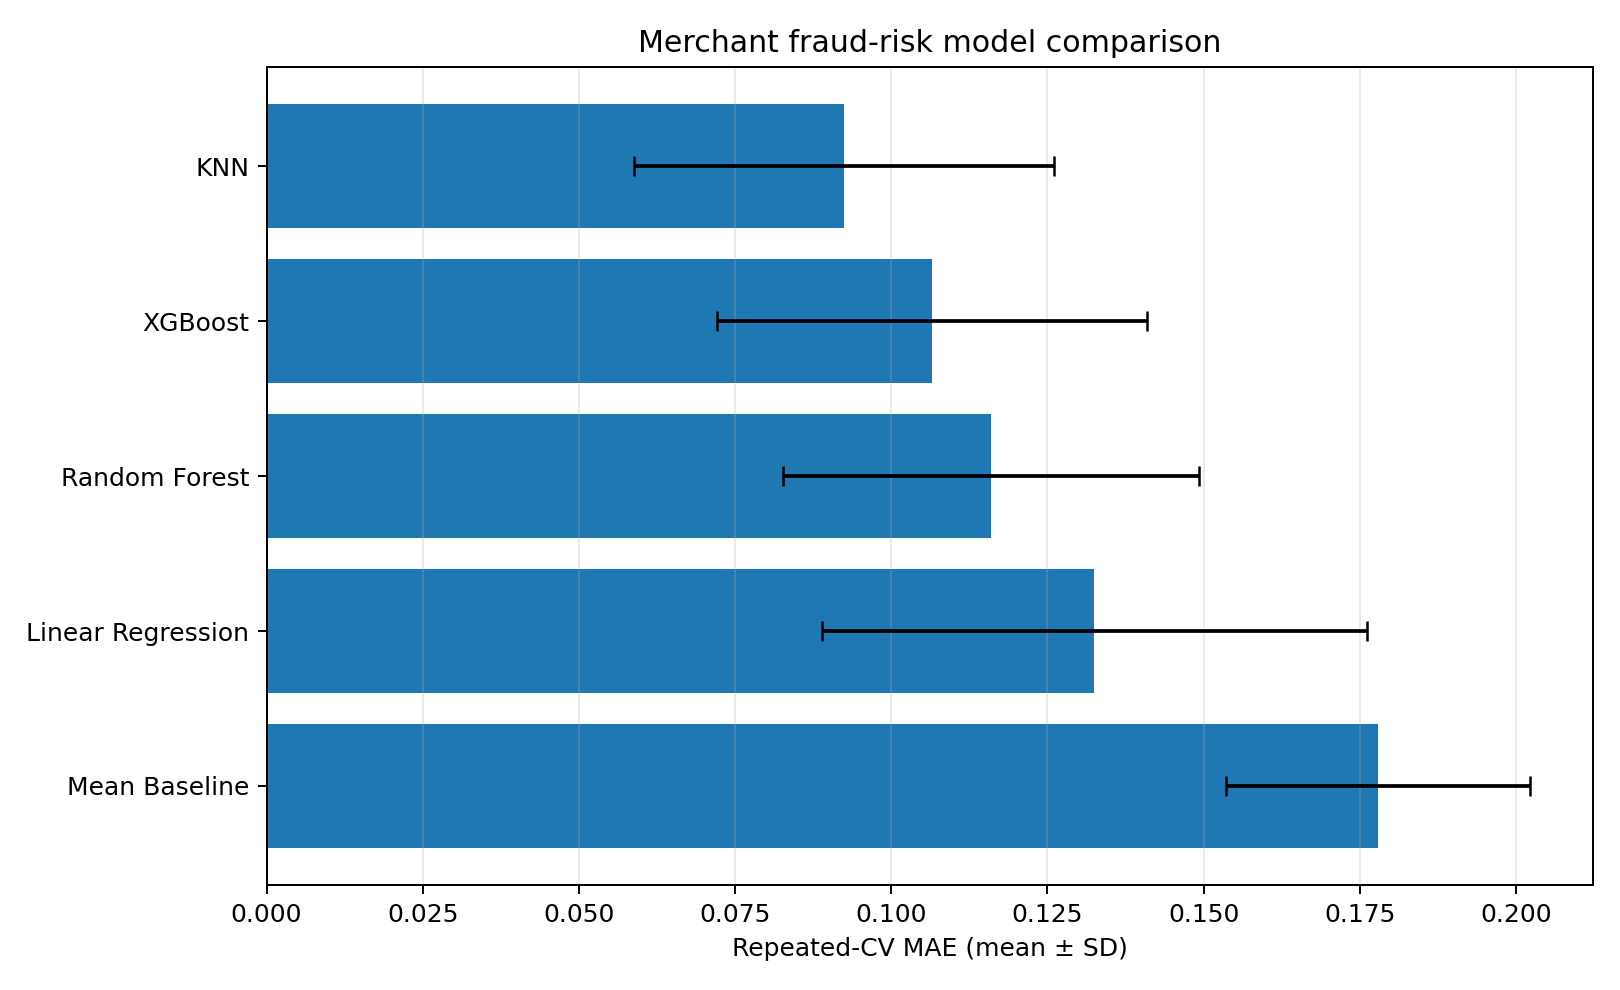

In [11]:
comparison = pd.read_csv(OUTPUT_DIR / 'merchant_model_comparison.csv')
nested_summary = pd.read_csv(OUTPUT_DIR / 'merchant_nested_cv_summary.csv')
loocv_summary = pd.read_csv(OUTPUT_DIR / 'merchant_loocv_summary.csv')
selected_features = pd.read_csv(OUTPUT_DIR / 'merchant_selected_features.csv')
feature_stability = pd.read_csv(OUTPUT_DIR / 'merchant_nested_feature_stability.csv')
display(comparison, forms, nested_summary, loocv_summary, selected_features, feature_stability)
display(Image(filename=str(OUTPUT_DIR / 'figures' / 'merchant_model_comparison.png')))
selected_name = comparison.loc[comparison.selected_by_cv, 'model'].iloc[0]
if selected_name in {'Random Forest', 'XGBoost'}:
    display(Image(filename=str(OUTPUT_DIR / 'figures' / 'merchant_selected_model_feature_importance.png')))

In [12]:
prediction_path = OUTPUT_DIR / 'merchant_fraud_predictions_all.parquet'
prediction_audit = duckdb.sql(f"""
    SELECT count(*) AS merchants,
           sum(merchant_fraud_label_available::INTEGER) AS directly_labelled_merchants,
           min(predicted_merchant_fraud_probability) AS min_prediction,
           avg(predicted_merchant_fraud_probability) AS mean_prediction,
           max(predicted_merchant_fraud_probability) AS max_prediction,
           count(DISTINCT predicted_merchant_fraud_probability) AS distinct_predictions
    FROM read_parquet('{prediction_path.as_posix()}')
""").df()
display(prediction_audit)
delivery_files = [
    'merchant_best_model_forms.csv',
    'merchant_data_split_summary.csv',
    'merchant_fraud_predictions_all.csv',
    'merchant_model_comparison.csv',
    'merchant_model_tuning_results.csv',
    'merchant_nested_cv_results.csv',
    'merchant_nested_cv_summary.csv',
    'merchant_nested_feature_stability.csv',
    'merchant_loocv_predictions.csv',
    'merchant_loocv_summary.csv',
    'merchant_selected_features.csv',
    'merchant_tree_feature_importance.csv',
]
DELIVERY_DIR.mkdir(parents=True, exist_ok=True)
for filename in delivery_files:
    source = OUTPUT_DIR / filename
    target = DELIVERY_DIR / filename
    target.write_bytes(source.read_bytes())
print('Delivered merchant CSV files to:', DELIVERY_DIR)

,merchants,directly_labelled_merchants,min_prediction,mean_prediction,max_prediction,distinct_predictions
0,4422,61.0,0.186108,0.547528,0.70636,4415


Delivered merchant CSV files to: C:\Users\十五\Documents\Codex\2026-09-03\https-chatgpt-com-share-6a98fa9e-e718\repo_latest\member4_fraud\result


## 11. Responsible interpretation

The selected score is a model estimate learned from only 61 directly labelled merchants. It must be combined with revenue, growth, repeat behaviour and coverage in the final ranking rather than used as an automatic exclusion rule. Consumer and merchant fraud scores are supplied probabilities, not confirmed events.